# 🌿 Plant Phenotyping from 3D Reconstruction (Ribes_04)

This notebook loads a ground-truth 3D reconstruction (point cloud + semantic labels + instance labels + confidence)
from Google Drive, performs **segmentation-based plant phenotyping**, computes **quantitative metrics**,
assesses **color-based plant health**, and produces **publication-quality visualizations**.

**Input (Google Drive):**
```
segmentation_jetcobot_internship/gt_reconstruction/
├── Ribes_04.ply
├── Ribes_04_Confidence.txt
├── Ribes_04_InstanceLabels.txt
└── Ribes_04_SemanticLabels.txt
```

**Output (Google Drive):**
```
segmentation_jetcobot_internship/outputs/pheno/
├── figures/          (PNG, 300 dpi, ready for report/paper)
├── metrics/          (CSV + JSON tables)
└── pheno_report.json (single consolidated summary)
```

> ⚠️ Run cells top to bottom. Adjust the **CONFIG** cell if your axis convention, background label id,
> or file names differ from the defaults.


## 1. Setup — install & import libraries

In [2]:
!pip install -q open3d plyfile scipy pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 102.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 90.9 MB/s eta 0:00:00


In [3]:
import os, json, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import ListedColormap
import seaborn as sns
from scipy.spatial import ConvexHull, cKDTree

import open3d as o3d

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.family"] = "DejaVu Sans"

print("open3d:", o3d.__version__)


open3d: 0.19.0


## 2. Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## 3. Configuration

Edit these if your setup differs.

In [5]:
# ---------------- CONFIG ----------------
DRIVE_ROOT   = "/content/drive/MyDrive/segmentation_jetcobot_internship"
GT_DIR       = os.path.join(DRIVE_ROOT, "gt_reconstruction")
OUT_DIR      = os.path.join(DRIVE_ROOT, "outputs", "pheno")
FIG_DIR      = os.path.join(OUT_DIR, "figures")
METRICS_DIR  = os.path.join(OUT_DIR, "metrics")

SAMPLE_NAME  = "Ribes_04"
PLY_PATH        = os.path.join(GT_DIR, f"{SAMPLE_NAME}.ply")
SEMANTIC_PATH   = os.path.join(GT_DIR, f"{SAMPLE_NAME}_SemanticLabels.txt")
INSTANCE_PATH   = os.path.join(GT_DIR, f"{SAMPLE_NAME}_InstanceLabels.txt")
CONFIDENCE_PATH = os.path.join(GT_DIR, f"{SAMPLE_NAME}_Confidence.txt")

# Which axis points "up" (plant height axis): 'x', 'y', or 'z'
AXIS_UP = "z"

# Label id treated as background / unlabeled (excluded from per-instance leaf stats)
BACKGROUND_SEMANTIC_LABEL = 0
BACKGROUND_INSTANCE_LABEL = 0

# Cap points drawn in scatter figures (metrics are always computed on the FULL cloud)
MAX_DISPLAY_POINTS = 60000

for d in [OUT_DIR, FIG_DIR, METRICS_DIR]:
    os.makedirs(d, exist_ok=True)

print("PLY:", PLY_PATH, "exists:", os.path.exists(PLY_PATH))
print("Semantic:", SEMANTIC_PATH, "exists:", os.path.exists(SEMANTIC_PATH))
print("Instance:", INSTANCE_PATH, "exists:", os.path.exists(INSTANCE_PATH))
print("Confidence:", CONFIDENCE_PATH, "exists:", os.path.exists(CONFIDENCE_PATH))
print("Outputs will be saved to:", OUT_DIR)


PLY: /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04.ply exists: True
Semantic: /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04_SemanticLabels.txt exists: True
Instance: /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04_InstanceLabels.txt exists: True
Confidence: /content/drive/MyDrive/segmentation_jetcobot_internship/gt_reconstruction/Ribes_04_Confidence.txt exists: True
Outputs will be saved to: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/pheno


## 4. Load point cloud + labels

Robust loader: handles label files that are single-column, whitespace-, or comma-separated.

In [6]:
def load_label_file(path, n_expected=None, dtype=float):
    """Load a per-point label/confidence .txt file, robust to delimiter differences."""
    arr = np.loadtxt(path, delimiter=None)  # whitespace, handles single/multi column
    arr = np.atleast_1d(arr).astype(dtype)
    if arr.ndim > 1:
        # If multiple columns, assume the label is the LAST column
        arr = arr[:, -1]
    if n_expected is not None and len(arr) != n_expected:
        raise ValueError(f"{path}: got {len(arr)} rows, expected {n_expected}")
    return arr

# --- Load point cloud ---
pcd = o3d.io.read_point_cloud(PLY_PATH)
points = np.asarray(pcd.points)
n_points = points.shape[0]
has_colors = pcd.has_colors()
colors = np.asarray(pcd.colors) if has_colors else None  # in [0,1]

print(f"Loaded {n_points:,} points. Has RGB colors: {has_colors}")

# --- Load labels ---
semantic = load_label_file(SEMANTIC_PATH, n_expected=n_points, dtype=int)
instance = load_label_file(INSTANCE_PATH, n_expected=n_points, dtype=int)
confidence = load_label_file(CONFIDENCE_PATH, n_expected=n_points, dtype=float)

print("Semantic labels: ", np.unique(semantic))
print("Instance count (unique ids):", len(np.unique(instance)))
print(f"Confidence range: [{confidence.min():.3f}, {confidence.max():.3f}], mean={confidence.mean():.3f}")

df_points = pd.DataFrame({
    "x": points[:, 0], "y": points[:, 1], "z": points[:, 2],
    "semantic": semantic, "instance": instance, "confidence": confidence,
})
if has_colors:
    df_points["r"] = (colors[:, 0] * 255).round().astype(int)
    df_points["g"] = (colors[:, 1] * 255).round().astype(int)
    df_points["b"] = (colors[:, 2] * 255).round().astype(int)

df_points.head()


Loaded 1,190,366 points. Has RGB colors: True
Semantic labels:  [1 2]
Instance count (unique ids): 33
Confidence range: [1.000, 177.000], mean=31.060


,x,y,z,semantic,instance,confidence,r,g,b
0,0.977595,7.676614,2.235206,2,33,1.0,86,70,46
1,0.977595,7.676614,2.235206,2,33,1.0,86,69,46
2,1.180705,7.672385,2.091533,2,33,2.0,97,83,51
3,1.077863,7.627170,2.053942,2,33,1.0,90,73,45
4,1.168191,7.681587,2.107812,2,33,1.0,103,93,57


## 5. Segmentation visualization (semantic + instance)

Three orthogonal views (front / side / top) for both semantic classes and individual plant organs (instances),
suitable for direct use in a report or paper figure.

In [7]:
axis_map = {"x": 0, "y": 1, "z": 2}
up_idx = axis_map[AXIS_UP]
other_idx = [i for i in range(3) if i != up_idx]

def subsample_idx(n, cap=MAX_DISPLAY_POINTS, seed=0):
    if n <= cap:
        return np.arange(n)
    rng = np.random.default_rng(seed)
    return rng.choice(n, size=cap, replace=False)

disp_idx = subsample_idx(n_points)
P = points[disp_idx]

def three_views(ax_row, color_vals, cmap, title_prefix, colorbar_label=None, discrete=False, legend_handles=None):
    view_defs = [("Front", other_idx[0], up_idx), ("Side", other_idx[1], up_idx), ("Top", other_idx[0], other_idx[1])]
    for ax, (name, ix, iy) in zip(ax_row, view_defs):
        sc = ax.scatter(P[:, ix], P[:, iy], c=color_vals, cmap=cmap, s=1.5, linewidths=0)
        ax.set_title(f"{title_prefix} — {name}")
        ax.set_aspect("equal", adjustable="datalim")
        ax.set_xticks([]); ax.set_yticks([])
    return sc

# ---- Semantic segmentation figure ----
sem_disp = semantic[disp_idx]
sem_classes = np.unique(semantic)
sem_cmap = ListedColormap(sns.color_palette("tab10", len(sem_classes)))
sem_lookup = {c: i for i, c in enumerate(sem_classes)}
sem_color_idx = np.vectorize(sem_lookup.get)(sem_disp)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sc = three_views(axes, sem_color_idx, sem_cmap, "Semantic segmentation")
cbar = fig.colorbar(sc, ax=axes, ticks=range(len(sem_classes)), shrink=0.8, pad=0.02)
cbar.ax.set_yticklabels([str(c) for c in sem_classes])
cbar.set_label("Semantic class id")
fig.suptitle(f"{SAMPLE_NAME} — Semantic Segmentation (3 views)", y=1.03, fontsize=16, fontweight="bold")
fig.savefig(os.path.join(FIG_DIR, "01_semantic_segmentation.png"), bbox_inches="tight")
plt.show()

# ---- Instance segmentation figure ----
inst_disp = instance[disp_idx]
inst_ids = np.unique(instance)
n_inst = len(inst_ids)
inst_cmap = ListedColormap(sns.color_palette("hls", n_inst))
inst_lookup = {c: i for i, c in enumerate(inst_ids)}
inst_color_idx = np.vectorize(inst_lookup.get)(inst_disp)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sc = three_views(axes, inst_color_idx, inst_cmap, "Instance segmentation")
fig.suptitle(f"{SAMPLE_NAME} — Instance Segmentation ({n_inst} organs/instances, 3 views)",
             y=1.03, fontsize=16, fontweight="bold")
fig.savefig(os.path.join(FIG_DIR, "02_instance_segmentation.png"), bbox_inches="tight")
plt.show()

# ---- Height map figure (structural reference) ----
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sc = three_views(axes, P[:, up_idx], "viridis", "Height (structure)")
cbar = fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label(f"{AXIS_UP.upper()} coordinate")
fig.suptitle(f"{SAMPLE_NAME} — Height Map", y=1.03, fontsize=16, fontweight="bold")
fig.savefig(os.path.join(FIG_DIR, "03_height_map.png"), bbox_inches="tight")
plt.show()

# ---- Confidence map figure ----
conf_disp = confidence[disp_idx]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sc = three_views(axes, conf_disp, "magma", "Label confidence")
cbar = fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label("Confidence")
fig.suptitle(f"{SAMPLE_NAME} — Confidence Map", y=1.03, fontsize=16, fontweight="bold")
fig.savefig(os.path.join(FIG_DIR, "04_confidence_map.png"), bbox_inches="tight")
plt.show()


Output hidden; open in https://colab.research.google.com to view.

## 6. Global phenotyping metrics

Whole-plant scale traits: bounding box dimensions, height, canopy width, convex-hull volume/area, point density.

In [8]:
def bbox_dims(pts):
    mins = pts.min(axis=0); maxs = pts.max(axis=0)
    return maxs - mins, mins, maxs

dims, mins, maxs = bbox_dims(points)
height = dims[up_idx]
width_a, width_b = [dims[i] for i in other_idx]

hull = ConvexHull(points)
hull_volume = hull.volume
hull_area = hull.area

bbox_volume = float(np.prod(dims))
density_bbox = n_points / bbox_volume if bbox_volume > 0 else np.nan
density_hull = n_points / hull_volume if hull_volume > 0 else np.nan

global_metrics = {
    "sample_name": SAMPLE_NAME,
    "n_points_total": int(n_points),
    "n_semantic_classes": int(len(sem_classes)),
    "n_instances": int(n_inst),
    "axis_up": AXIS_UP,
    "plant_height": float(height),
    "canopy_width_1": float(width_a),
    "canopy_width_2": float(width_b),
    "bounding_box_dims_xyz": dims.tolist(),
    "bounding_box_volume": bbox_volume,
    "convex_hull_volume": float(hull_volume),
    "convex_hull_surface_area": float(hull_area),
    "point_density_per_bbox_volume": float(density_bbox),
    "point_density_per_hull_volume": float(density_hull),
    "mean_confidence": float(confidence.mean()),
    "median_confidence": float(np.median(confidence)),
    "min_confidence": float(confidence.min()),
    "max_confidence": float(confidence.max()),
}

with open(os.path.join(METRICS_DIR, "global_metrics.json"), "w") as f:
    json.dump(global_metrics, f, indent=2)

pd.DataFrame([global_metrics])


,sample_name,n_points_total,n_semantic_classes,n_instances,axis_up,plant_height,canopy_width_1,canopy_width_2,bounding_box_dims_xyz,bounding_box_volume,convex_hull_volume,convex_hull_surface_area,point_density_per_bbox_volume,point_density_per_hull_volume,mean_confidence,median_confidence,min_confidence,max_confidence
0,Ribes_04,1190366,2,33,z,34.637649,21.713918,22.159561,"[21.713918298723463, 22.159561034886, 34.63764...",16666.628453,7324.699813,2097.873593,71.422124,162.513964,31.06022,25.0,1.0,177.0


## 7. Per-class (semantic) metrics

In [9]:
sem_rows = []
for c in sem_classes:
    mask = semantic == c
    n = int(mask.sum())
    pts_c = points[mask]
    row = {
        "semantic_class": int(c),
        "n_points": n,
        "pct_of_total": 100 * n / n_points,
        "mean_confidence": float(confidence[mask].mean()) if n else np.nan,
        "centroid_x": float(pts_c[:, 0].mean()) if n else np.nan,
        "centroid_y": float(pts_c[:, 1].mean()) if n else np.nan,
        "centroid_z": float(pts_c[:, 2].mean()) if n else np.nan,
    }
    if n >= 4:
        try:
            row["convex_hull_volume"] = float(ConvexHull(pts_c).volume)
        except Exception:
            row["convex_hull_volume"] = np.nan
    else:
        row["convex_hull_volume"] = np.nan
    sem_rows.append(row)

df_semantic = pd.DataFrame(sem_rows).sort_values("n_points", ascending=False).reset_index(drop=True)
df_semantic.to_csv(os.path.join(METRICS_DIR, "semantic_class_metrics.csv"), index=False)
df_semantic


,semantic_class,n_points,pct_of_total,mean_confidence,centroid_x,centroid_y,centroid_z,convex_hull_volume
0,2,1015670,85.324178,35.784585,4.353118,12.281581,20.928445,7224.139190
1,1,174696,14.675822,3.593105,3.830369,11.628338,14.598578,2028.415912


## 8. Per-instance (per-organ, e.g. leaf/stem) metrics

For each instance id: point count, centroid, bounding-box based length/width/thickness (via PCA),
approximate surface area / volume, and mean confidence & color-health index (computed in section 9).

In [10]:
def pca_extent(pts):
    """Principal-axis extents (length, width, thickness) of a point set."""
    c = pts.mean(axis=0)
    X = pts - c
    cov = np.cov(X.T)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvecs = eigvecs[:, order]
    proj = X @ eigvecs
    extents = proj.max(axis=0) - proj.min(axis=0)
    return extents  # [length, width, thickness] along principal axes

inst_rows = []
for iid in inst_ids:
    mask = instance == iid
    n = int(mask.sum())
    pts_i = points[mask]
    row = {
        "instance_id": int(iid),
        "semantic_class_majority": int(pd.Series(semantic[mask]).mode().iloc[0]) if n else np.nan,
        "n_points": n,
        "mean_confidence": float(confidence[mask].mean()) if n else np.nan,
        "centroid_x": float(pts_i[:, 0].mean()) if n else np.nan,
        "centroid_y": float(pts_i[:, 1].mean()) if n else np.nan,
        "centroid_z": float(pts_i[:, 2].mean()) if n else np.nan,
    }
    if n >= 3:
        ext = pca_extent(pts_i)
        row["length"], row["width"], row["thickness"] = [float(v) for v in ext]
    else:
        row["length"] = row["width"] = row["thickness"] = np.nan
    if n >= 4:
        try:
            row["convex_hull_volume"] = float(ConvexHull(pts_i).volume)
        except Exception:
            row["convex_hull_volume"] = np.nan
    else:
        row["convex_hull_volume"] = np.nan
    inst_rows.append(row)

df_instance = pd.DataFrame(inst_rows).sort_values("n_points", ascending=False).reset_index(drop=True)
df_instance.to_csv(os.path.join(METRICS_DIR, "instance_metrics.csv"), index=False)

n_organs = (df_instance["instance_id"] != BACKGROUND_INSTANCE_LABEL).sum()
print(f"Detected organ instances (excluding background id={BACKGROUND_INSTANCE_LABEL}): {n_organs}")
df_instance.head(15)


Detected organ instances (excluding background id=0): 33


,instance_id,semantic_class_majority,n_points,mean_confidence,centroid_x,centroid_y,centroid_z,length,width,thickness,convex_hull_volume
0,1,1,174696,3.593105,3.830369,11.628338,14.598578,34.676724,17.057543,9.543509,2028.415912
1,8,2,74112,14.912848,11.586401,12.321713,27.850284,7.729949,5.004266,3.068935,49.097136
2,4,2,69528,40.218933,-3.536267,3.373460,19.674203,7.233785,6.325760,2.086176,41.645726
3,20,2,59992,65.575477,6.220036,16.797845,33.730860,7.244981,6.245528,2.640510,46.473732
4,14,2,59223,50.078331,-0.704112,12.765306,19.371729,7.800999,7.209570,1.431559,35.782081
5,10,2,57937,43.570171,13.111897,19.147544,29.060733,6.810729,5.653605,2.434643,38.296207
6,11,2,56228,48.695721,5.371523,20.457024,20.468552,6.880514,7.342125,2.017448,34.631580
7,2,2,49103,31.159603,12.011120,12.199407,5.027685,6.063161,5.183555,1.790869,24.027874
8,9,2,47792,59.563944,13.005164,14.246113,31.450205,6.376712,6.103103,2.305630,31.957331
9,19,2,46745,39.465098,-0.497028,14.305548,25.310887,6.649652,4.733067,2.349638,31.803014


## 9. Color-based plant health assessment

RGB-only vegetation indices (no NIR available) computed per point:

- **ExG** = 2G − R − B (Excess Green)
- **ExR** = 1.4R − G (Excess Red)
- **ExGR** = ExG − ExR (Excess Green minus Excess Red)
- **GLI** = (2G − R − B) / (2G + R + B) (Green Leaf Index)
- **VARI** = (G − R) / (G + R − B) (Visible Atmospherically Resistant Index)
- **NGRDI** = (G − R) / (G + R) (Normalized Green-Red Difference Index)

Points are classified into health categories from VARI / NGRDI, following common RGB-based
vegetation-stress conventions (green→healthy, yellow-green→chlorotic/stressed, brown/red→necrotic).

In [11]:
if not has_colors:
    print("⚠️ Point cloud has no RGB colors — skipping color-based health assessment.")
    df_health = pd.DataFrame()
else:
    R = colors[:, 0].astype(float)
    G = colors[:, 1].astype(float)
    B = colors[:, 2].astype(float)
    eps = 1e-6

    ExG = 2 * G - R - B
    ExR = 1.4 * R - G
    ExGR = ExG - ExR
    GLI = (2 * G - R - B) / (2 * G + R + B + eps)
    VARI = (G - R) / (G + R - B + eps)
    NGRDI = (G - R) / (G + R + eps)

    df_points["ExG"] = ExG
    df_points["ExGR"] = ExGR
    df_points["GLI"] = GLI
    df_points["VARI"] = VARI
    df_points["NGRDI"] = NGRDI

    veg_mask = ExGR > 0  # basic vegetation vs. background/soil/pot separation

    def classify_health(vari, ngrdi):
        if vari > 0.15 and ngrdi > 0.10:
            return "Healthy (vigorous green)"
        elif vari > 0.02:
            return "Moderate (light green)"
        elif vari > -0.10:
            return "Stressed / chlorotic (yellowing)"
        else:
            return "Necrotic / senescent (brown-red)"

    health_labels = np.array([classify_health(v, n) for v, n in zip(VARI, NGRDI)])
    df_points["health_category"] = health_labels

    health_order = ["Healthy (vigorous green)", "Moderate (light green)",
                     "Stressed / chlorotic (yellowing)", "Necrotic / senescent (brown-red)"]
    health_counts = pd.Series(health_labels).value_counts().reindex(health_order, fill_value=0)
    health_pct = 100 * health_counts / len(health_labels)

    df_health = pd.DataFrame({
        "health_category": health_order,
        "n_points": health_counts.values,
        "pct_of_total": health_pct.values,
    })
    df_health.to_csv(os.path.join(METRICS_DIR, "health_category_summary.csv"), index=False)

    # per-instance mean health index (useful to flag individual unhealthy leaves in the paper)
    df_instance_health = (
        df_points.groupby("instance")[["ExG", "GLI", "VARI", "NGRDI"]].mean().reset_index()
        .rename(columns={"instance": "instance_id"})
    )
    df_instance = df_instance.merge(df_instance_health, on="instance_id", how="left")
    df_instance.to_csv(os.path.join(METRICS_DIR, "instance_metrics.csv"), index=False)  # overwrite with health cols

    color_health_summary = {
        "vegetation_fraction_pct": float(100 * veg_mask.mean()),
        "mean_ExG": float(ExG.mean()), "mean_GLI": float(GLI.mean()),
        "mean_VARI": float(VARI.mean()), "mean_NGRDI": float(NGRDI.mean()),
        "health_category_pct": {k: float(v) for k, v in zip(health_order, health_pct.values)},
    }
    with open(os.path.join(METRICS_DIR, "color_health_summary.json"), "w") as f:
        json.dump(color_health_summary, f, indent=2)

    display(df_health)
    display(df_instance[["instance_id", "n_points", "ExG", "GLI", "VARI", "NGRDI"]].head(15))


,health_category,n_points,pct_of_total
0,Healthy (vigorous green),763128,64.108686
1,Moderate (light green),187732,15.770948
2,Stressed / chlorotic (yellowing),77086,6.475823
3,Necrotic / senescent (brown-red),162420,13.644543


,instance_id,n_points,ExG,GLI,VARI,NGRDI
0,1,174696,0.081919,0.067127,0.622525,-0.055195
1,8,74112,0.224911,0.245392,0.210695,0.151471
2,4,69528,0.218195,0.212177,0.143598,0.103701
3,20,59992,0.245413,0.162286,0.194825,0.120944
4,14,59223,0.200530,0.227190,0.211942,0.148958
5,10,57937,0.255739,0.204582,0.180377,0.122990
6,11,56228,0.300406,0.242845,0.185872,0.137298
7,2,49103,0.255588,0.164482,0.126074,0.083475
8,9,47792,0.307962,0.204483,0.217060,0.143959
9,19,46745,0.201849,0.206131,0.173040,0.119399


### 9.1 Health visualization

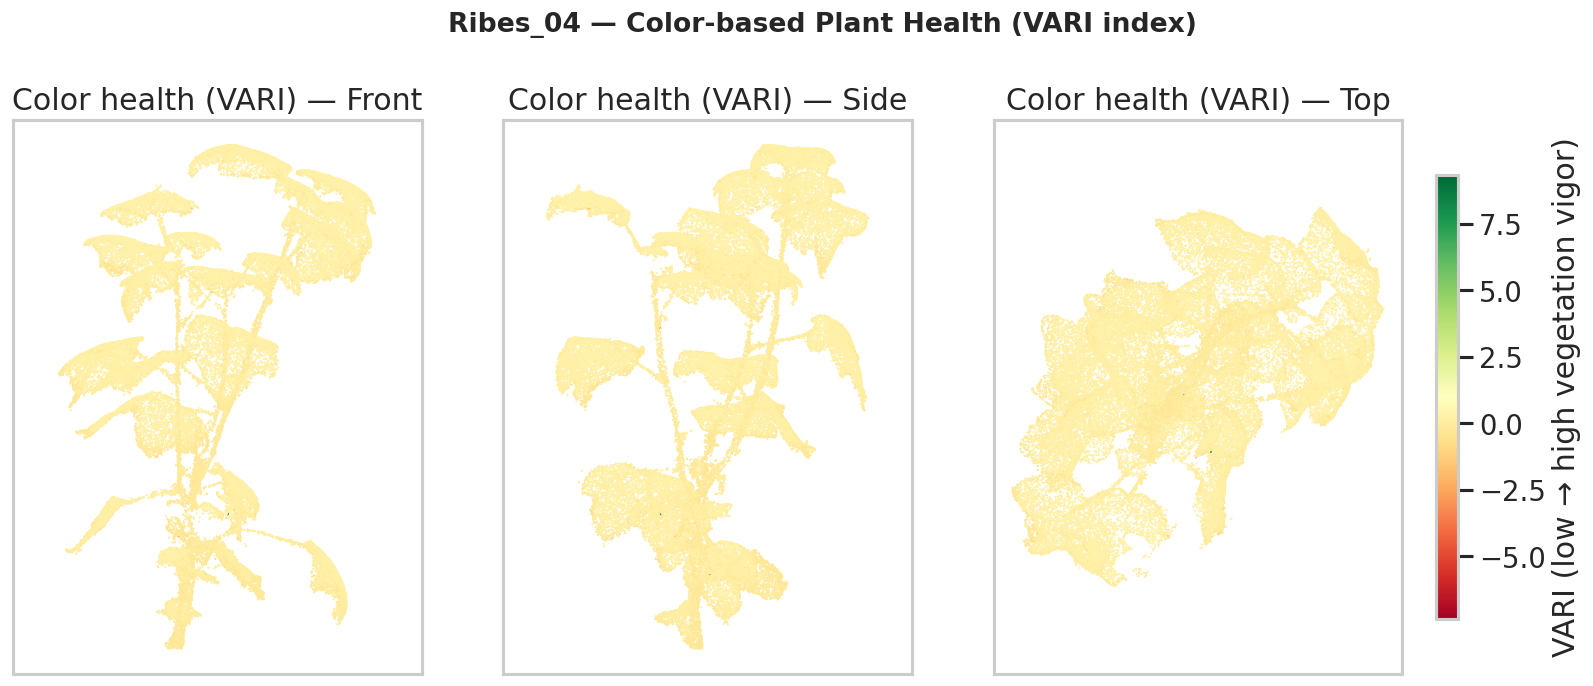

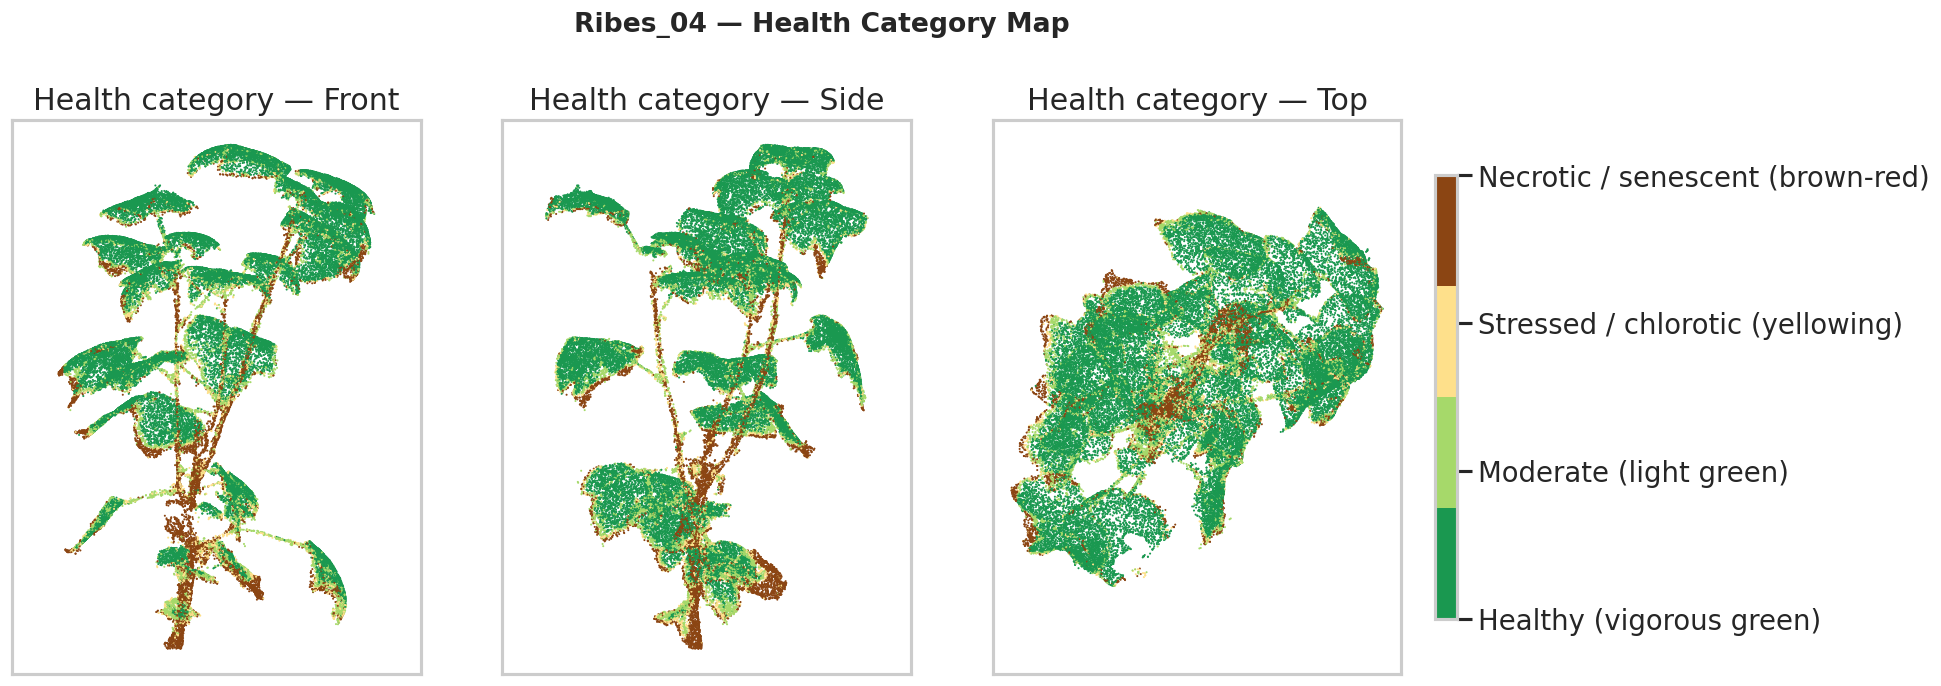

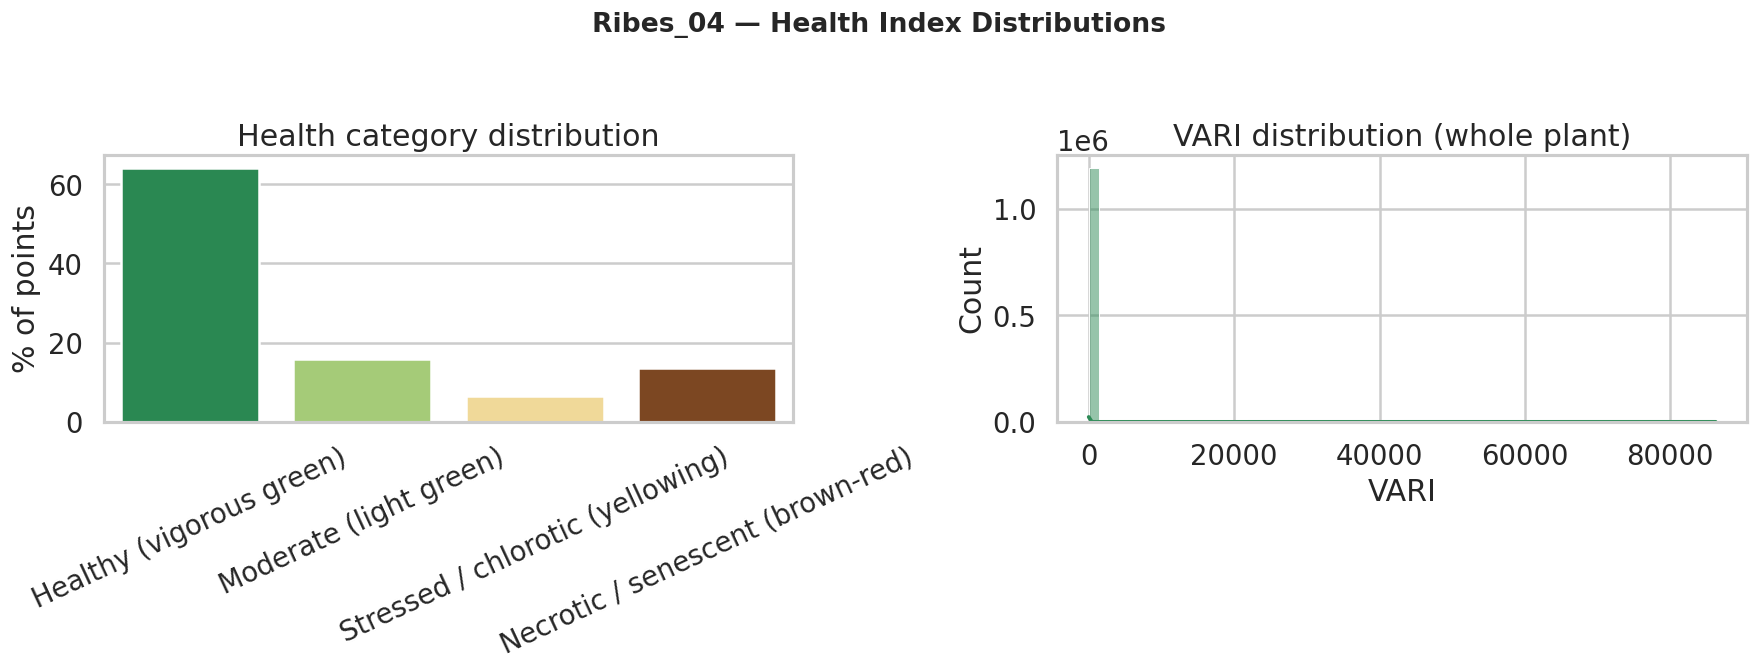

In [12]:
if has_colors:
    vari_disp = df_points["VARI"].values[disp_idx]
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sc = three_views(axes, vari_disp, "RdYlGn", "Color health (VARI)")
    cbar = fig.colorbar(sc, ax=axes, shrink=0.8, pad=0.02)
    cbar.set_label("VARI (low → high vegetation vigor)")
    fig.suptitle(f"{SAMPLE_NAME} — Color-based Plant Health (VARI index)", y=1.03, fontsize=16, fontweight="bold")
    fig.savefig(os.path.join(FIG_DIR, "05_color_health_map.png"), bbox_inches="tight")
    plt.show()

    # health category categorical map
    health_disp = df_points["health_category"].values[disp_idx]
    cat_lookup = {c: i for i, c in enumerate(health_order)}
    health_idx_disp = np.vectorize(cat_lookup.get)(health_disp)
    health_cmap = ListedColormap(["#1a9850", "#a6d96a", "#fee08b", "#8b4513"])
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    sc = three_views(axes, health_idx_disp, health_cmap, "Health category")
    cbar = fig.colorbar(sc, ax=axes, ticks=range(4), shrink=0.8, pad=0.02)
    cbar.ax.set_yticklabels(health_order)
    fig.suptitle(f"{SAMPLE_NAME} — Health Category Map", y=1.03, fontsize=16, fontweight="bold")
    fig.savefig(os.path.join(FIG_DIR, "06_health_category_map.png"), bbox_inches="tight")
    plt.show()

    # distribution plots
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    sns.barplot(data=df_health, x="health_category", y="pct_of_total",
                palette=["#1a9850", "#a6d96a", "#fee08b", "#8b4513"], ax=axes[0])
    axes[0].set_ylabel("% of points"); axes[0].set_xlabel("")
    axes[0].tick_params(axis='x', rotation=25)
    axes[0].set_title("Health category distribution")

    sns.histplot(df_points["VARI"], bins=60, kde=True, color="seagreen", ax=axes[1])
    axes[1].set_title("VARI distribution (whole plant)")
    axes[1].set_xlabel("VARI")

    fig.suptitle(f"{SAMPLE_NAME} — Health Index Distributions", y=1.03, fontsize=16, fontweight="bold")
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "07_health_distributions.png"), bbox_inches="tight")
    plt.show()


## 10. Publication-ready summary dashboard

A single multi-panel figure combining structure, segmentation, and health — convenient for a paper's main figure.

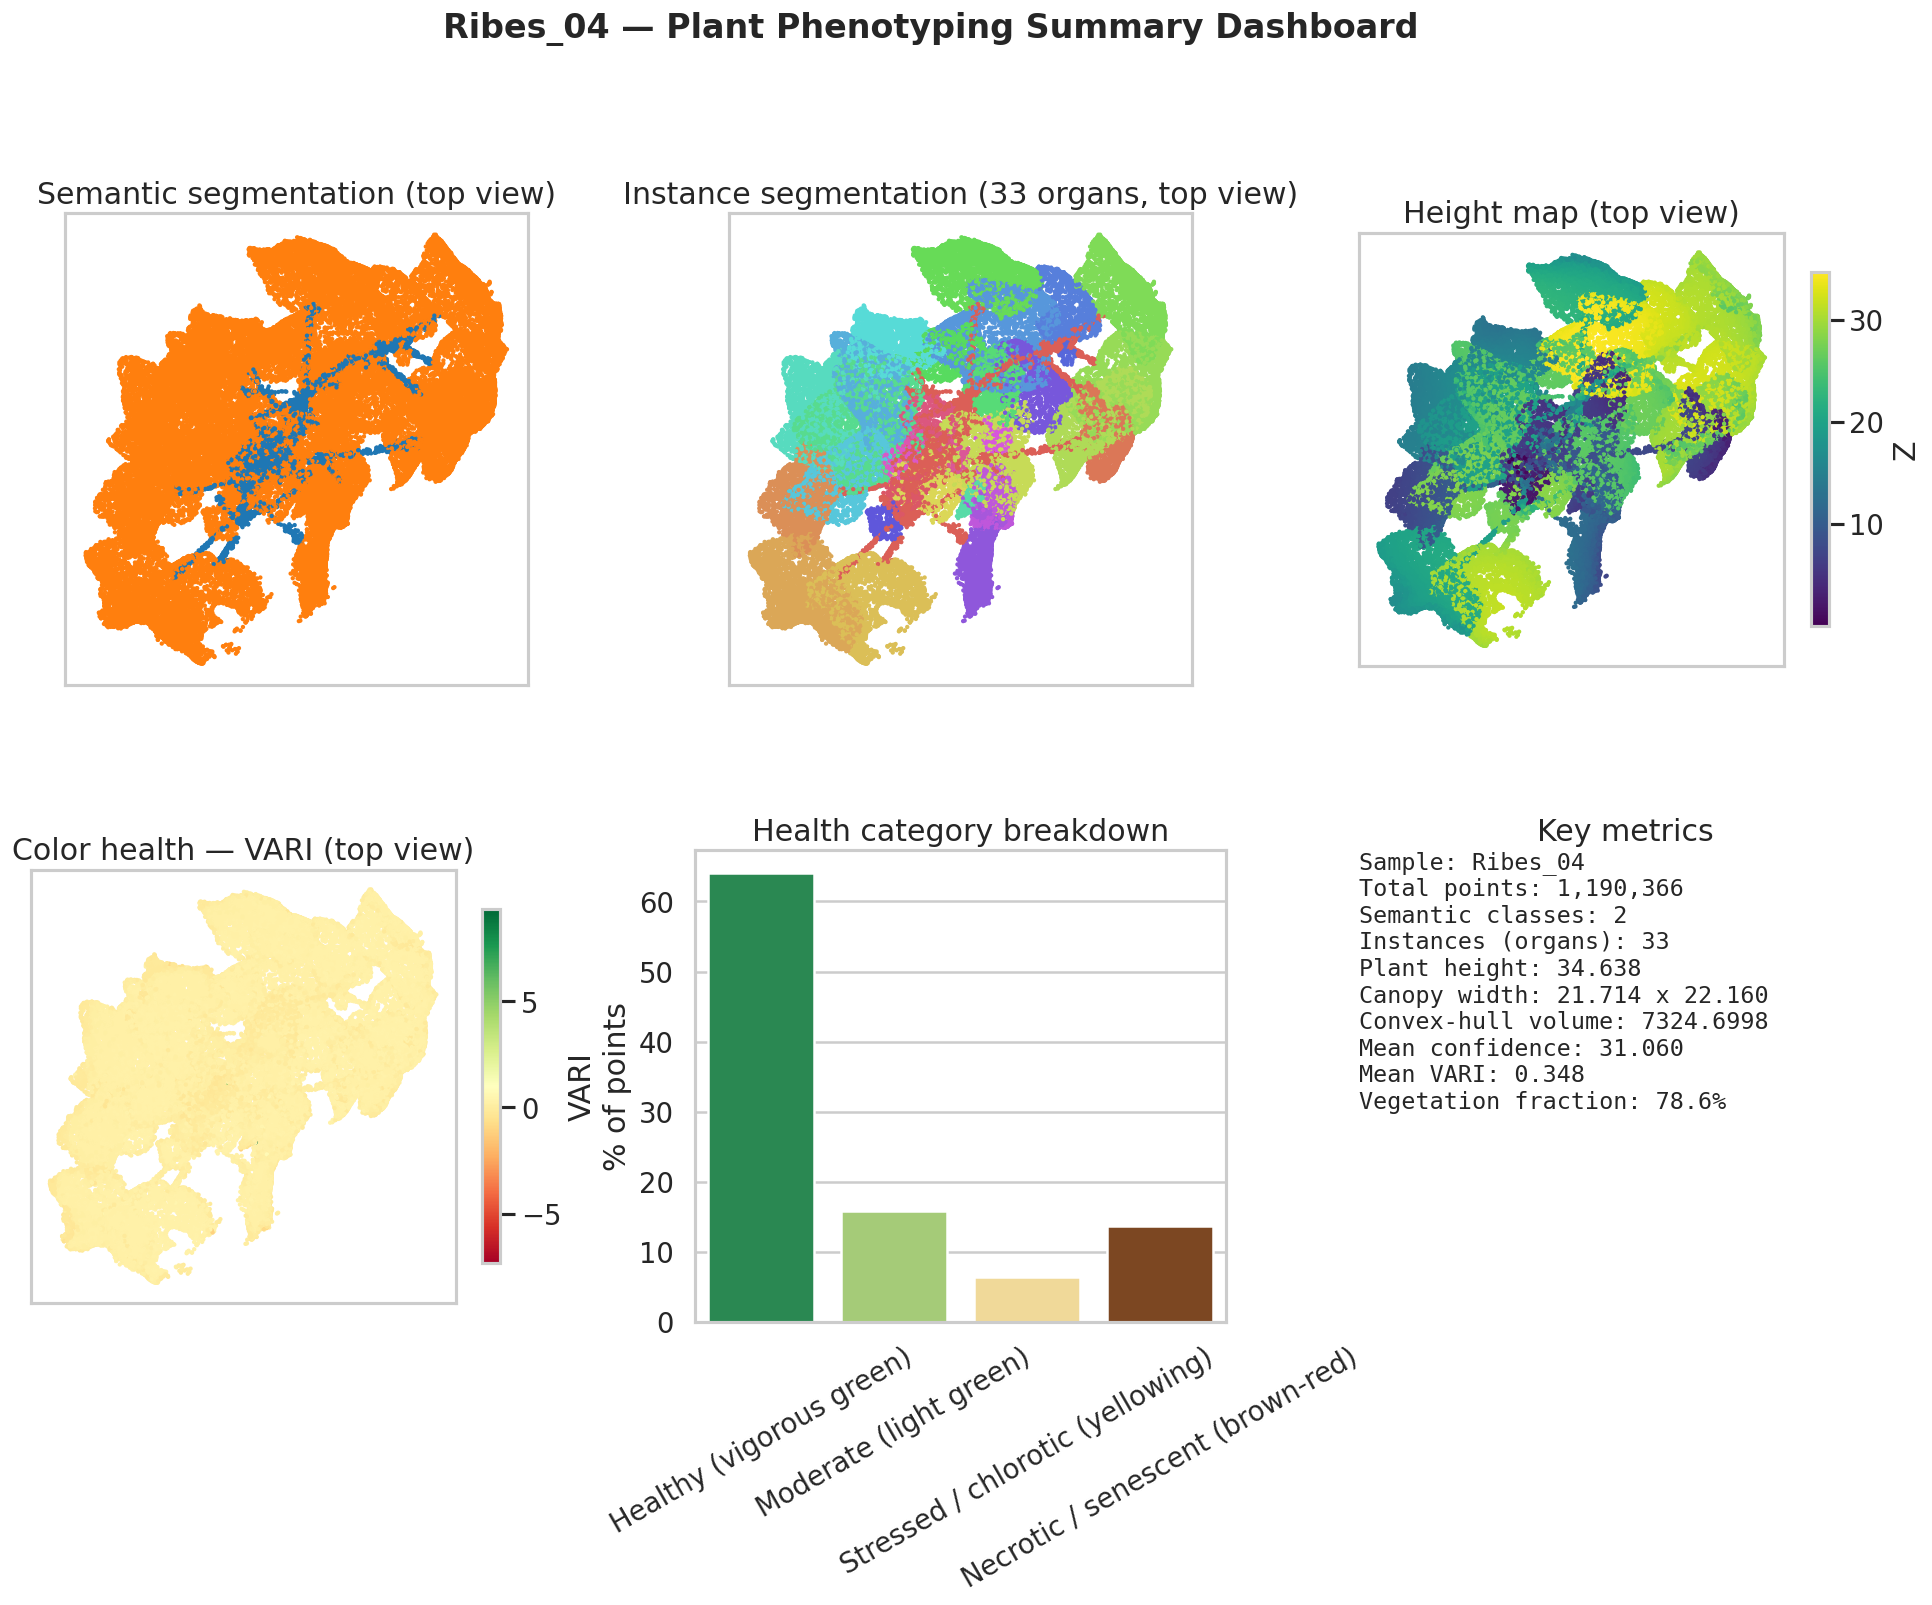

In [13]:
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.25)

# Top view semantic
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(P[:, other_idx[0]], P[:, other_idx[1]], c=sem_color_idx, cmap=sem_cmap, s=1.2)
ax1.set_title("Semantic segmentation (top view)"); ax1.set_aspect("equal"); ax1.set_xticks([]); ax1.set_yticks([])

# Top view instance
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(P[:, other_idx[0]], P[:, other_idx[1]], c=inst_color_idx, cmap=inst_cmap, s=1.2)
ax2.set_title(f"Instance segmentation ({n_inst} organs, top view)"); ax2.set_aspect("equal"); ax2.set_xticks([]); ax2.set_yticks([])

# Top view height
ax3 = fig.add_subplot(gs[0, 2])
sc3 = ax3.scatter(P[:, other_idx[0]], P[:, other_idx[1]], c=P[:, up_idx], cmap="viridis", s=1.2)
ax3.set_title("Height map (top view)"); ax3.set_aspect("equal"); ax3.set_xticks([]); ax3.set_yticks([])
fig.colorbar(sc3, ax=ax3, shrink=0.75, label=f"{AXIS_UP.upper()}")

# Top view health
ax4 = fig.add_subplot(gs[1, 0])
if has_colors:
    sc4 = ax4.scatter(P[:, other_idx[0]], P[:, other_idx[1]], c=vari_disp, cmap="RdYlGn", s=1.2)
    fig.colorbar(sc4, ax=ax4, shrink=0.75, label="VARI")
ax4.set_title("Color health — VARI (top view)"); ax4.set_aspect("equal"); ax4.set_xticks([]); ax4.set_yticks([])

# Health category bars
ax5 = fig.add_subplot(gs[1, 1])
if has_colors:
    sns.barplot(data=df_health, x="health_category", y="pct_of_total",
                palette=["#1a9850", "#a6d96a", "#fee08b", "#8b4513"], ax=ax5)
    ax5.tick_params(axis='x', rotation=30)
ax5.set_ylabel("% of points"); ax5.set_xlabel(""); ax5.set_title("Health category breakdown")

# Key metrics text panel
ax6 = fig.add_subplot(gs[1, 2]); ax6.axis("off")
text_lines = [
    f"Sample: {SAMPLE_NAME}",
    f"Total points: {n_points:,}",
    f"Semantic classes: {len(sem_classes)}",
    f"Instances (organs): {n_inst}",
    f"Plant height: {height:.3f}",
    f"Canopy width: {width_a:.3f} x {width_b:.3f}",
    f"Convex-hull volume: {hull_volume:.4f}",
    f"Mean confidence: {confidence.mean():.3f}",
]
if has_colors:
    text_lines += [
        f"Mean VARI: {VARI.mean():.3f}",
        f"Vegetation fraction: {100*veg_mask.mean():.1f}%",
    ]
ax6.text(0, 1, "\n".join(text_lines), va="top", ha="left", fontsize=14, family="monospace")
ax6.set_title("Key metrics")

fig.suptitle(f"{SAMPLE_NAME} — Plant Phenotyping Summary Dashboard", fontsize=20, fontweight="bold", y=1.02)
fig.savefig(os.path.join(FIG_DIR, "08_summary_dashboard.png"), bbox_inches="tight")
plt.show()


## 11. Consolidated report (for paper / thesis appendix)

In [14]:
report = {
    "sample_name": SAMPLE_NAME,
    "global_metrics": global_metrics,
    "n_semantic_classes": int(len(sem_classes)),
    "n_instances": int(n_inst),
    "semantic_class_table": df_semantic.to_dict(orient="records"),
    "instance_table_preview": df_instance.head(20).to_dict(orient="records"),
    "color_health_summary": color_health_summary if has_colors else None,
    "health_category_table": df_health.to_dict(orient="records") if has_colors else None,
    "output_files": {
        "figures_dir": FIG_DIR,
        "metrics_dir": METRICS_DIR,
    },
}

report_path = os.path.join(OUT_DIR, "pheno_report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Saved consolidated report to:", report_path)
print()
print("All outputs saved under:", OUT_DIR)
for root, _, files in os.walk(OUT_DIR):
    for fname in sorted(files):
        print(" -", os.path.relpath(os.path.join(root, fname), OUT_DIR))


Saved consolidated report to: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/pheno/pheno_report.json

All outputs saved under: /content/drive/MyDrive/segmentation_jetcobot_internship/outputs/pheno
 - pheno_report.json
 - figures/01_semantic_segmentation.png
 - figures/02_instance_segmentation.png
 - figures/03_height_map.png
 - figures/04_confidence_map.png
 - figures/05_color_health_map.png
 - figures/06_health_category_map.png
 - figures/07_health_distributions.png
 - figures/08_summary_dashboard.png
 - metrics/color_health_summary.json
 - metrics/global_metrics.json
 - metrics/health_category_summary.csv
 - metrics/instance_metrics.csv
 - metrics/semantic_class_metrics.csv


---
### Notes for the report / paper

- If leaf/organ count from **Section 8** doesn't match expectations, check `BACKGROUND_INSTANCE_LABEL` in the CONFIG cell.
- If height/width look swapped, check `AXIS_UP` in the CONFIG cell (should match the reconstruction's vertical axis).
- The color-health indices (ExG/GLI/VARI/NGRDI) are **RGB-only proxies** for vigor — no NIR/multispectral data was used, so treat
  "health" labels as relative/qualitative rather than a calibrated physiological measurement; state this clearly in the methods section.
- All figures are saved at 300 dpi (`figures/`) and all tables as CSV/JSON (`metrics/`) — ready to drop into a report or LaTeX paper.
